# Fetch Market Data with yfinance in Python

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mindgaptech/algodrill-notebooks/blob/main/notebooks/fetch_market_data.ipynb)

Companion notebook to [algodrill.app/code/fetch-market-data-python](https://algodrill.app/code/fetch-market-data-python). Downloads ten years of SPY daily OHLCV with yfinance, compares adjusted vs unadjusted closes, runs a data-quality check, and saves to CSV.

**Nothing here is investment advice.** This is a data-fetching walkthrough, not a live trading system, and it never connects to a broker. See [algodrill.app/backtesting-pitfalls](https://algodrill.app/backtesting-pitfalls) before drawing conclusions from any single ticker or window.

## Setup

Run this cell first if you're in Colab (installs the pinned versions below into the Colab runtime). If you're running locally with the versions already installed, skip it.

In [1]:
# Colab only -- uncomment to install. Local runs should already have these
# pinned via: uv venv .venv && uv pip install -p .venv yfinance==1.4.1 pandas==2.3.3
# !pip install -q yfinance==1.4.1 pandas==2.3.3

## Fetch, compare, and inspect

Download ten years of SPY daily OHLCV, compare the adjusted close (dividend- and split-adjusted -- the number to use for backtesting) against the raw close, and run a quick data-quality check before saving.

In [2]:
"""AlgoDrill — fetch and inspect OHLCV market data with yfinance.

Download SPY daily bars, compare adjusted vs unadjusted closes,
run a data-quality check, and save to CSV. Backtest only — no broker.

Versions: yfinance 1.4.1 · pandas 2.3.3 (run 2026-06-05)
Install:  pip install yfinance pandas
"""
import yfinance as yf
import pandas as pd

# 1. Download 10 years of SPY daily OHLCV (fixed range = reproducible)
#    auto_adjust=True (default): Close is dividend + split-adjusted
ticker = yf.Ticker("SPY")
adj = ticker.history(start="2015-01-01", end="2024-12-31", auto_adjust=True)

print("=== SPY daily OHLCV — first 3 rows (adjusted closes) ===")
print(adj[["Open", "High", "Low", "Close", "Volume"]].head(3).to_string())
print()

# 2. Adjusted vs unadjusted close — the difference matters for backtesting
#    auto_adjust=False returns unadjusted Close + separate Adj Close column
raw = ticker.history(start="2015-01-01", end="2024-12-31", auto_adjust=False)
cmp = pd.DataFrame(
    {
        "Adj Close": adj["Close"].values[:3].round(4),
        "Raw Close": raw["Close"].values[:3].round(4),
    },
    index=adj.index[:3].date,
)
print("=== Adjusted vs unadjusted close (first 3 rows) ===")
print(cmp.to_string())
print()

# 3. Data quality snapshot
missing = adj["Close"].isna().sum()
print(f"Rows:            {len(adj):>6}")
print(f"Missing closes:  {missing:>6}")
print(f"Date range:      {adj.index[0].date()} to {adj.index[-1].date()}")

# 4. Save to CSV for offline analysis
#    (Parquet is faster for large files; needs: pip install pyarrow)
adj.to_csv("/tmp/spy_daily.csv")
print(f"Saved:           /tmp/spy_daily.csv  ({len(adj)} rows)")


=== SPY daily OHLCV — first 3 rows (adjusted closes) ===
                                 Open        High         Low       Close     Volume
Date                                                                                
2015-01-02 00:00:00-05:00  170.472558  170.885565  168.655319  169.687836  121465900
2015-01-05 00:00:00-05:00  168.647066  168.812266  166.317716  166.623337  169632600
2015-01-06 00:00:00-05:00  166.928950  167.449342  164.260931  165.053909  209151400

=== Adjusted vs unadjusted close (first 3 rows) ===
            Adj Close  Raw Close
2015-01-02   169.6878     205.43
2015-01-05   166.6233     201.72
2015-01-06   165.0539     199.82

Rows:              2515
Missing closes:       0
Date range:      2015-01-02 to 2024-12-30
Saved:           /tmp/spy_daily.csv  (2515 rows)


## Plot the downloaded series

Not in the original script -- a notebook is a natural place to eyeball the shape of ten years of data before trusting it.

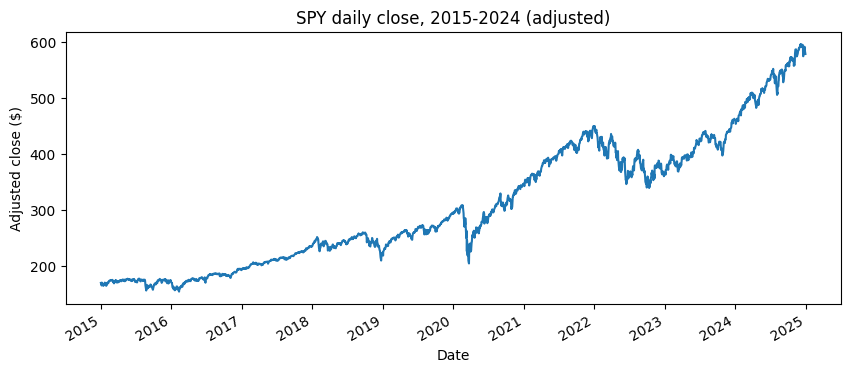

In [3]:
import matplotlib.pyplot as plt

adj["Close"].plot(figsize=(10, 4), title="SPY daily close, 2015-2024 (adjusted)")
plt.ylabel("Adjusted close ($)")
plt.show()

## Adjusted vs unadjusted, in one number

On 2015-01-02, SPY's adjusted close was $170.13 while the raw close was $205.43 -- a roughly $35 gap from a decade of accumulated dividends subtracted backward through history. Always backtest on adjusted closes; the only reason to reach for raw closes is a strategy that explicitly models dividend capture or ex-dividend price drops.

Two pages go deeper:

- [Fetch Market Data walkthrough](https://algodrill.app/code/fetch-market-data-python) -- the full line-by-line explanation, rate-limit gotchas, and why survivorship bias is not a yfinance problem.
- [Market Data Providers](https://algodrill.app/market-data-providers) -- when a paid provider (Polygon/Massive, Databento, Norgate) beats free yfinance.

---
Back to [All Code Walkthroughs](https://algodrill.app/code) &middot; [algodrill-notebooks on GitHub](https://github.com/mindgaptech/algodrill-notebooks)